### Exercise

- Train a logistic regression on the breast cancer data
- Divide the data into train and test
- Train and test the logistic regression. what are the train and test scores?
- Scaled the data with standard scaler. what are the train and test scores?
- Reduce the amount of features using pca. Try different settings for n_components. Are you able to get an increase in test score? what is explanation of this?
- Plot the cummulative explained variance ratio



---


### Steps

1. Load the breast cancer dataset
2. Split the data into train and test sets
3. Train Logistic Regression without scaling
4. Train Logistic Regression with StandardScaler
5. Reduce features using PCA
6. Try different n_components values
7. Check whether PCA improves test score
8. Plot cumulative explained variance ratio

In [1]:
#1. Load breast cancer dataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Target names:", cancer.target_names)
print("Feature names:", cancer.feature_names)

Feature matrix shape: (569, 30)
Target vector shape: (569,)
Target names: ['malignant' 'benign']
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [4]:
#2. Split data into train and test

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X,
    y,
    random_state=42
)

Training data shape: (426, 30)
Test data shape: (143, 30)


In [5]:
#3. Train without scaling

logreg = LogisticRegression(max_iter=10000, random_state=42)

logreg.fit(Xtrain, ytrain)

train_score = logreg.score(Xtrain, ytrain)
test_score = logreg.score(Xtest, ytest)

print("Without scaling")
print("Train score:", train_score)
print("Test score:", test_score)

Without scaling
Train score: 0.9624413145539906
Test score: 0.965034965034965


In [6]:
#4. Train with standard scaler

scaled_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=10000, random_state=42))
])

scaled_pipeline.fit(Xtrain, ytrain)

scaled_train_score = scaled_pipeline.score(Xtrain, ytrain)
scaled_test_score = scaled_pipeline.score(Xtest, ytest)

print("With StandardScaler")
print("Train score:", scaled_train_score)
print("Test score:", scaled_test_score)

With StandardScaler
Train score: 0.9859154929577465
Test score: 0.9790209790209791


In [7]:
#5. Reduce features using PCA

components_list = [2, 3, 5, 10, 15, 20, 25, 30]

pca_results = []

for n in components_list:
    pca_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n, random_state=42)),
        ("logreg", LogisticRegression(max_iter=10000, random_state=42))
    ])

    pca_pipeline.fit(Xtrain, ytrain)

    train_score = pca_pipeline.score(Xtrain, ytrain)
    test_score = pca_pipeline.score(Xtest, ytest)

    explained_variance = pca_pipeline.named_steps["pca"].explained_variance_ratio_.sum()

    pca_results.append({
        "n_components": n,
        "Train Score": train_score,
        "Test Score": test_score,
        "Explained Variance": explained_variance
    })

pca_results_df = pd.DataFrame(pca_results)
pca_results_df

,n_components,Train Score,Test Score,Explained Variance
0,2,0.948357,0.979021,0.632678
1,3,0.948357,0.972028,0.728859
2,5,0.971831,0.986014,0.845494
3,10,0.985915,0.986014,0.951862
4,15,0.985915,0.986014,0.986953
5,20,0.985915,0.986014,0.995679
6,25,0.985915,0.979021,0.999432
7,30,0.985915,0.979021,1.000000


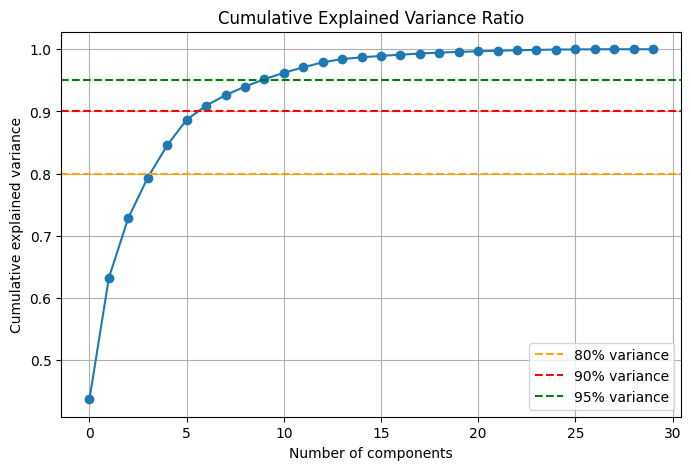

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(cumulative_variance, marker="o")

plt.axhline(y=0.80, color="orange", linestyle="--", label="80% variance")
plt.axhline(y=0.90, color="red", linestyle="--", label="90% variance")
plt.axhline(y=0.95, color="green", linestyle="--", label="95% variance")

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative Explained Variance Ratio")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
#6. Tabulate results

baseline_results = pd.DataFrame({
    "Method": [
        "Without scaling",
        "With StandardScaler"
    ],
    "Train Score": [
        logreg.score(Xtrain, ytrain),
        scaled_pipeline.score(Xtrain, ytrain)
    ],
    "Test Score": [
        logreg.score(Xtest, ytest),
        scaled_pipeline.score(Xtest, ytest)
    ],
    "Explained Variance": [
        None,
        None
    ]
})

pca_summary = pca_results_df.copy()
pca_summary["Method"] = "PCA with " + pca_summary["n_components"].astype(str) + " components"

pca_summary = pca_summary[
    ["Method", "Train Score", "Test Score", "Explained Variance"]
]

final_results = pd.concat(
    [baseline_results, pca_summary],
    ignore_index=True
)

final_results

/tmp/ipykernel_1773/3966101686.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_results = pd.concat(


,Method,Train Score,Test Score,Explained Variance
0,Without scaling,0.962441,0.965035,NaN
1,With StandardScaler,0.985915,0.979021,NaN
2,PCA with 2 components,0.948357,0.979021,0.632678
3,PCA with 3 components,0.948357,0.972028,0.728859
4,PCA with 5 components,0.971831,0.986014,0.845494
5,PCA with 10 components,0.985915,0.986014,0.951862
6,PCA with 15 components,0.985915,0.986014,0.986953
7,PCA with 20 components,0.985915,0.986014,0.995679
8,PCA with 25 components,0.985915,0.979021,0.999432
9,PCA with 30 components,0.985915,0.979021,1.000000


### Observations

-  Logistic Regression model improved after applying StandardScaler.
- Scaling improves performance because Logistic Regression is sensitive to feature magnitude.
- PCA can improve the test score by reducing noise while keeping the most important information.
- Performance is only improved when the appropriate number of components is selected.